In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

dat=pd.read_csv('run17.csv')

In [22]:
dat
dat.dropna()

,bib,name,sex,age,city,net_sec,clock_sec,pace_sec,event
0,6,Hiwot G.,F,21.0,Ethiopia,3217.0,3217.0,321.0,10 Mile
1,22,Buze D.,F,22.0,Ethiopia,3232.0,3232.0,323.0,10 Mile
2,16,Gladys K.,F,31.0,Kenya,3276.0,3276.0,327.0,10 Mile
3,4,Mamitu D.,F,33.0,Ethiopia,3285.0,3285.0,328.0,10 Mile
4,20,Karolina N.,F,35.0,Poland,3288.0,3288.0,328.0,10 Mile
...,...,...,...,...,...,...,...,...,...
19956,23701,David M.,M,65.0,"Auburn, AZ",4319.0,4403.0,1388.0,5K
19957,15179,Edward S.,M,40.0,"Eldersburg, MD",4500.0,4675.0,1446.0,5K
19958,23421,John P.,M,67.0,"Baltimore, MD",4501.0,4674.0,1447.0,5K
19959,25160,Jony R.,M,37.0,"Woodbridge, VA",5287.0,5334.0,1700.0,5K


(array([  18.,   81.,  277.,  505.,  457.,  332.,  238.,  252.,  185.,
         175.,  195.,  282.,  399.,  608.,  851., 1103., 1286., 1514.,
        1617., 1608., 1628., 1417., 1257.,  992.,  793.,  575.,  482.,
         395.,  239.,  197.]),
 array([1078., 1322., 1566., 1810., 2054., 2298., 2542., 2786., 3030.,
        3274., 3518., 3762., 4006., 4250., 4494., 4738., 4982., 5226.,
        5470., 5714., 5958., 6202., 6446., 6690., 6934., 7178., 7422.,
        7666., 7910., 8154., 8398.]),
 <BarContainer object of 30 artists>)

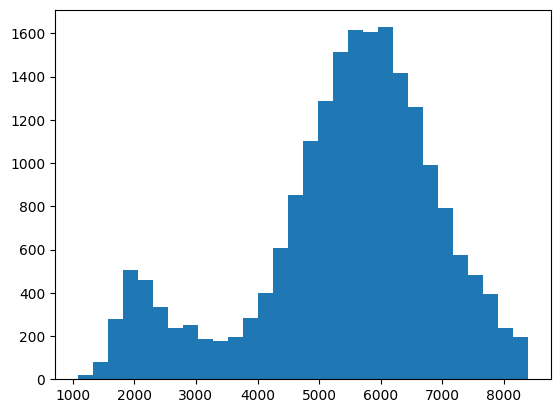

In [5]:
plt.hist(dat['net_sec'], bins=30)

In [23]:
def e_step(x, mu_0, mu_1, pi_0, pi_1):
    lik_0=pi_0*(1/(np.sqrt(2*np.pi)*1000))*np.e**(-((x-mu_0)**2)/(2*1000**2))
    lik_1=pi_1*(1/(np.sqrt(2*np.pi)*1000))*np.e**(-((x-mu_1)**2)/(2*1000**2))
    resp_0=lik_0/(lik_0+lik_1)
    resp_1=lik_1/(lik_0+lik_1)
    return resp_0, resp_1

def m_step(x, resp_0, resp_1):
    mu_0=np.sum(x*resp_0)/np.sum(resp_0)
    mu_1=np.sum(x*resp_1)/np.sum(resp_1)
    pi_0=np.mean(resp_0)
    pi_1=np.mean(resp_1)
    return mu_0, mu_1, pi_0, pi_1

x=np.array(dat['net_sec'].dropna())
print(x)
mu_0, mu_1 = 3000, 8000
pi_0, pi_1=0.5,0.5
for i in range(100):
    resp_0, resp_1 = e_step(x, mu_0, mu_1,pi_0,pi_1)
    mu_0,mu_1, pi_0, pi_1 =m_step(x, resp_0, resp_1)

print(mu_0, mu_1)

[3217. 3232. 3276. ... 4501. 5287. 5287.]
2597.2217565384813 5899.780356962932


In [24]:
(np.e-2)/6.5

0.11050489668600694

In [20]:
import numpy as np

def _logsumexp(a, b):
    """log(exp(a)+exp(b)) in a stable way, elementwise."""
    m = np.maximum(a, b)
    return m + np.log(np.exp(a - m) + np.exp(b - m))

def e_step_logspace(x, mu0, mu1, pi0, pi1, sigma=1000.0, eps=1e-12):
    # log N(x | mu, sigma^2) up to constants
    # (keeping constants is fine too; they cancel, but this is stable either way)
    logc = -0.5*np.log(2*np.pi) - np.log(sigma)
    logp0 = np.log(pi0 + eps) + logc - 0.5*((x - mu0)/sigma)**2
    logp1 = np.log(pi1 + eps) + logc - 0.5*((x - mu1)/sigma)**2

    denom = _logsumexp(logp0, logp1)
    r0 = np.exp(logp0 - denom)
    r1 = np.exp(logp1 - denom)
    return r0, r1

def m_step(x, r0, r1, eps=1e-12):
    n0 = np.sum(r0) + eps
    n1 = np.sum(r1) + eps
    mu0 = np.sum(r0 * x) / n0
    mu1 = np.sum(r1 * x) / n1
    pi0 = n0 / (len(x) + 2*eps)
    pi1 = n1 / (len(x) + 2*eps)

    # optional: keep labels ordered so it doesn't "flip"
    if mu0 > mu1:
        mu0, mu1 = mu1, mu0
        pi0, pi1 = pi1, pi0
    return mu0, mu1, pi0, pi1

# ---- data hygiene (THIS is the #1 culprit) ----
x = np.asarray(dat["net_sec"], dtype=float)
x = x[np.isfinite(x)]           # drops NaN/inf
# if you suspect strings like "5,123": you'd need preprocessing before dtype=float

# ---- initialize more sanely than (3000,8000) if needed ----
mu0, mu1 = np.percentile(x, [20, 80])
pi0, pi1 = 0.5, 0.5

for it in range(200):
    r0, r1 = e_step_logspace(x, mu0, mu1, pi0, pi1, sigma=1000.0)
    mu0_new, mu1_new, pi0_new, pi1_new = m_step(x, r0, r1)

    # stop if converged
    if max(abs(mu0_new-mu0), abs(mu1_new-mu1)) < 1e-6:
        mu0, mu1, pi0, pi1 = mu0_new, mu1_new, pi0_new, pi1_new
        break

    mu0, mu1, pi0, pi1 = mu0_new, mu1_new, pi0_new, pi1_new

print("mu:", mu0, mu1)
print("pi:", pi0, pi1)


mu: 2597.221757248994 5899.780357098008
pi: 0.14286894646230755 0.8571310535376923


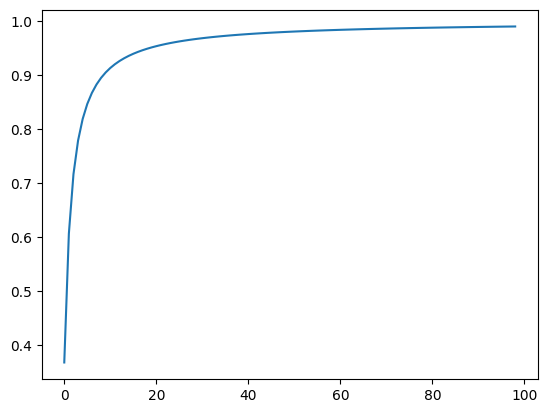

In [27]:
n=np.array(range(1,100,1))
d=np.e**(-1/n)

plt.plot(d)